# Khám phá dữ liệu (EDA): AG News

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from datasets import load_dataset

sns.set(style='whitegrid')

In [2]:
plt.rcParams['figure.figsize'] = (10, 5)

ds_train = load_dataset('ag_news', split='train')
ds_test = load_dataset('ag_news', split='test')

print(f"Số mẫu train: {len(ds_train)}")
print(f"Số mẫu test: {len(ds_test)}")

Số mẫu train: 120000
Số mẫu test: 7600


In [3]:
train_texts = [" ".join(x['text'].split()) for x in ds_train]
train_labels = [int(x['label']) for x in ds_train]

test_texts = [" ".join(x['text'].split()) for x in ds_test]
test_labels = [int(x['label']) for x in ds_test]

def show_examples(texts, labels, n_per_class=3):
    samples = {}
    for t, l in zip(texts, labels):
        samples.setdefault(l, []).append(t)
    for l in sorted(samples.keys()):
        print(f"\n--- Lớp {l} (một vài ví dụ) ---")
        for s in samples[l][:n_per_class]:
            print('-', s[:300])

show_examples(train_texts, train_labels)


--- Lớp 0 (một vài ví dụ) ---
- Venezuelans Vote Early in Referendum on Chavez Rule (Reuters) Reuters - Venezuelans turned out early\and in large numbers on Sunday to vote in a historic referendum\that will either remove left-wing President Hugo Chavez from\office or give him a new mandate to govern for the next two\years.
- S.Koreans Clash with Police on Iraq Troop Dispatch (Reuters) Reuters - South Korean police used water cannon in\central Seoul Sunday to disperse at least 7,000 protesters\urging the government to reverse a controversial decision to\send more troops to Iraq.
- Palestinians in Israeli Jails Start Hunger Strike (Reuters) Reuters - Thousands of Palestinian\prisoners in Israeli jails began a hunger strike for better\conditions Sunday, but Israel's security minister said he\didn't care if they starved to death.

--- Lớp 1 (một vài ví dụ) ---
- Phelps, Thorpe Advance in 200 Freestyle (AP) AP - Michael Phelps took care of qualifying for the Olympic 200-meter freestyle sem

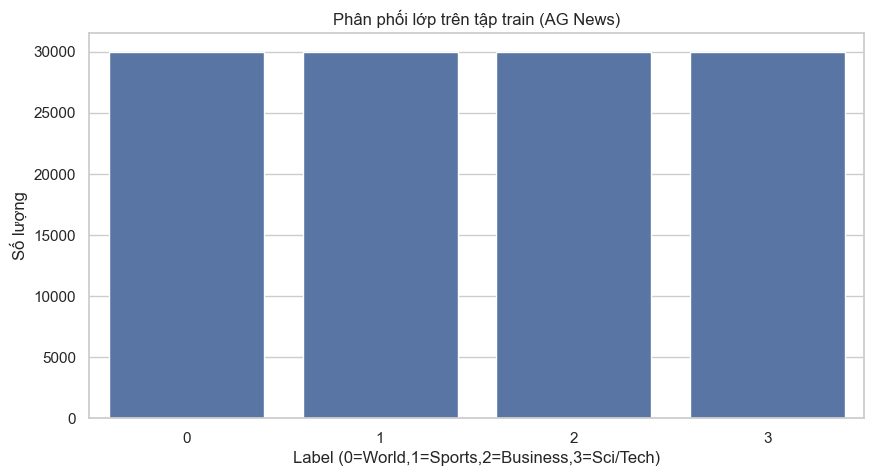

In [4]:
label_counts = Counter(train_labels)
labels = list(label_counts.keys())
counts = [label_counts[l] for l in labels]

plt.figure()
sns.barplot(x=labels, y=counts)
plt.title('Phân phối lớp trên tập train (AG News)')
plt.xlabel('Label (0=World,1=Sports,2=Business,3=Sci/Tech)')
plt.ylabel('Số lượng')
plt.show()

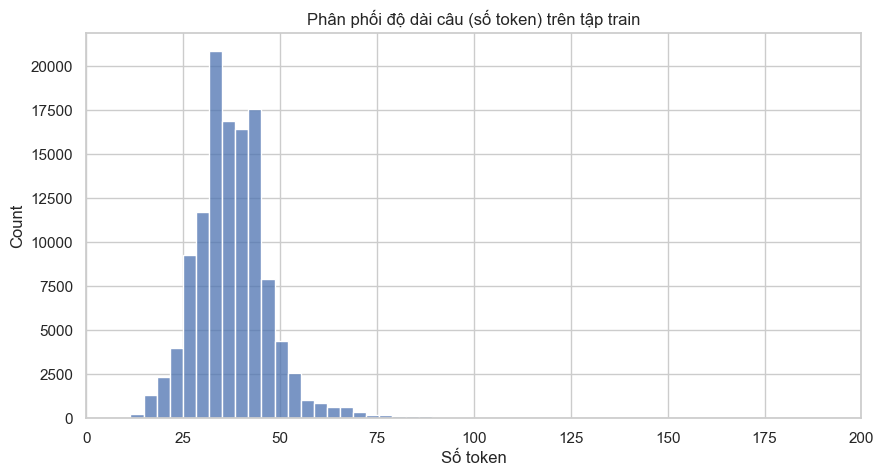

In [5]:
train_lens = [len(t.split()) for t in train_texts]
plt.figure()
sns.histplot(train_lens, bins=50)
plt.xlim(0, 200)
plt.title('Phân phối độ dài câu (số token) trên tập train')
plt.xlabel('Số token')
plt.show()

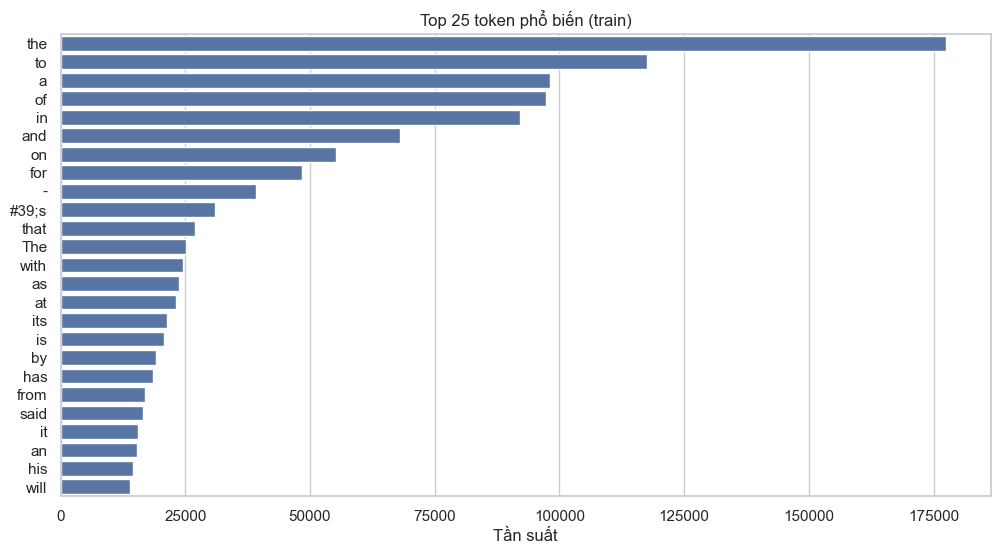

In [6]:
counter = Counter()
for t in train_texts:
    counter.update(t.split())

TOP_K = 25
most_common = counter.most_common(TOP_K)
words, freqs = zip(*most_common)

plt.figure(figsize=(12,6))
sns.barplot(x=list(freqs), y=list(words))
plt.title(f'Top {TOP_K} token phổ biến (train)')
plt.xlabel('Tần suất')
plt.show()

In [7]:
print('\nKích thước vocab (số từ khác nhau):', len(counter))
print('Top 20 token:', most_common[:20])


Kích thước vocab (số từ khác nhau): 188110
Top 20 token: [('the', 177529), ('to', 117605), ('a', 98112), ('of', 97395), ('in', 92055), ('and', 68046), ('on', 55156), ('for', 48430), ('-', 39105), ('#39;s', 30928), ('that', 26988), ('The', 25054), ('with', 24531), ('as', 23641), ('at', 23186), ('its', 21390), ('is', 20708), ('by', 19048), ('has', 18605), ('from', 16928)]
